# Baseline Dependency — Parallel Seeds

This notebook parallelises the **inner loop over `dataset_seeds`** while keeping *all* model
`.fit(...)` calls (GLM, DRN, DDR, CANN, MDN) with different distributional assumptions. At the end it **saves the CSV** with
the same naming convention as the original.


## Imports & setup

In [ ]:
import os
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# Your packages
import drn
from drn import GLM, CONSTANT, CANN, MDN, DDR, DRN  # classes used below
from generate_synthetic_dataset import generate_synthetic_baseline_dependency
from analysis_utils import calculate_metrics  

# Parallel tools
from joblib import Parallel, delayed

# Keep per-process math libs to a single thread by default
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
torch.set_num_threads(1)

VERSION = "ds3"

# Detect accelerator and choose worker count
accelerator = "gpu" if torch.cuda.is_available() else "cpu"
MAX_WORKERS = min(20, (os.cpu_count() or 1)) if accelerator == "cpu" else 1
print(f"Using {accelerator}; max parallel workers = {MAX_WORKERS}")


Using cpu; max parallel workers = 8


/Users/ericdong/opt/anaconda3/envs/project1_runpod/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Output dirs & shared test set

In [2]:
TABLE_DIR = Path("tables/baseline-test/")
TABLE_DIR.mkdir(parents=True, exist_ok=True)

PLOT_DIR = Path("plots/baseline-test/")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Shared large test set (raw, unstandardised; preprocessing happens per worker)
X_TEST_RAW_SHARED, y_test_raw_shared, _, _ = generate_synthetic_baseline_dependency(
    100_000, seed=131313, version=VERSION
)
NUM_FEATURES = X_TEST_RAW_SHARED.shape[1]
X_TEST_RAW_SHARED = pd.DataFrame(
    X_TEST_RAW_SHARED, columns=[f"X_{i+1}" for i in range(NUM_FEATURES)]
)
Y_TEST_SHARED = torch.Tensor(y_test_raw_shared.values).flatten()

X_TEST_RAW_SHARED.head(3)

-0.0009075867533256465 4.201016727020175


,X_1,X_2
0,0.277662,0.309128
1,-0.046519,0.954623
2,1.598068,-0.257124


## Seeds, sizes & training hyperparameters

In [3]:
# Reproduce the original seed construction
np.random.seed(424242)
NUM_DATASET_SEEDS = 20
dataset_seeds = [int(s) for s in np.random.randint(0, 2**32 - 1, size=NUM_DATASET_SEEDS)]

# You can run the full list if you like; by default we only evaluate 6000 for parity
SIZES = [3_000, 6_000, 12_000]
EVAL_SIZES = [3_000]

@dataclass
class TrainParams:
    proportion: float     # proportion used for DRN cutpoints
    hidden_size: int
    dropout_rate: float
    num_hidden_layers: int
    lr: float
    batch_size: int
    patience: int
    kl_alpha: float
    dv_alpha: float

# Reasonable defaults matching the spirit of your original notebook
SIZE_TO_PARAMS = {
    3000: TrainParams(
        proportion=0.2,
        hidden_size=256,
        dropout_rate=0.0, 
        num_hidden_layers=4,
        lr=1e-3/4,
        batch_size=128,
        patience=20,
        kl_alpha=2e-3,
        dv_alpha=2e-3,
    ),
    6000: TrainParams(
        proportion=0.1,
        hidden_size=256,
        dropout_rate=0.0, 
        num_hidden_layers=4,
        lr=1e-3/4,
        batch_size=128,
        patience=20,
        kl_alpha=1e-3,
        dv_alpha=1e-3,
    ),
    12000: TrainParams(
        proportion=0.05,
        hidden_size=256,
        dropout_rate=0.0, 
        num_hidden_layers=4,
        lr=1e-3/4,
        batch_size=128,
        patience=20,
        kl_alpha=5e-4,
        dv_alpha=5e-4,
    ),
}

MAX_SEEDS_TO_RUN = 20
seeds_to_run = dataset_seeds[:MAX_SEEDS_TO_RUN]
SIZES, EVAL_SIZES, len(seeds_to_run)

([3000, 6000, 12000], [3000], 20)

## Worker function (top‑level & picklable)
This contains the **entire inner body** of your original loop, including all model `.fit(...)` calls and metric computation. It returns a `pandas.DataFrame` for one `(size, seed)` pair.

In [ ]:
def run_one_seed_for_size(size: int, dataset_seed: int, seed_index: int):
    # Keep each worker single-threaded (important on large CPUs)
    os.environ.setdefault("OMP_NUM_THREADS", "1")
    os.environ.setdefault("MKL_NUM_THREADS", "1")
    torch.set_num_threads(1)

    params = SIZE_TO_PARAMS[int(size)]
    n_train = int(size)
    n_val = int(size / 3)

    # ----- Generate train/val data -----
    X_train_np, y_train_series, _, _ = generate_synthetic_baseline_dependency(
        n_train, seed=int(dataset_seed + 1), version=VERSION
    )
    X_val_np, y_val_series, _, _ = generate_synthetic_baseline_dependency(
        n_val,   seed=int(dataset_seed + 1), version=VERSION
    )

    X_train = pd.DataFrame(X_train_np, columns=[f"X_{j+1}" for j in range(NUM_FEATURES)])
    X_val   = pd.DataFrame(X_val_np,   columns=[f"X_{j+1}" for j in range(NUM_FEATURES)])
    Y_train = torch.Tensor(y_train_series.values).flatten()
    Y_val   = torch.Tensor(y_val_series.values).flatten()

    # ----- Preprocess (standardise) -----
    X_train, X_val, x_test_raw_shared, ct, _ = drn.preprocess_data(
        X_train,
        X_val,
        X_TEST_RAW_SHARED,
        num_features=[f"X_{j+1}" for j in range(NUM_FEATURES)],
        cat_features=[],
    )

    # ----- Baselines -----
    torch.manual_seed(23)
    glm_null = Constant('gamma').fit(X_train, y_train_series)
    glm = GLM('gamma').fit(X_train, y_train_series)
    glm_gaussian_null = Constant('gaussian').fit(X_train, y_train_series)
    glm_gaussian = GLM('gaussian').fit(X_train, y_train_series)

    # ----- DRN cutpoints -----
    cutpoints = drn.default_drn_cutpoints(y_train_series, params.proportion, 5)
    cutpoints_gaussian = [-15] + cutpoints

    # ----- DRN (Gamma) -----
    print('Training DRN_GAMMA')
    torch.manual_seed(23)
    drn_gamma = DRN(
        baseline=glm,
        cutpoints=cutpoints,
        loss_metric="jbce",
        kl_alpha=params.kl_alpha,
        dv_alpha=params.dv_alpha,
        hidden_size=params.hidden_size,
        num_hidden_layers=params.num_hidden_layers,
        dropout_rate=params.dropout_rate,
        learning_rate=params.lr,
        baseline_min_prob_mass=1e-3,
    ).fit(
        X_train, y_train_series,
        X_val,   y_val_series,
        epochs=2000, patience=params.patience, batch_size=params.batch_size,
        enable_progress_bar=False,
        enable_model_summary=False,
    )

    # ----- DRN (Gamma null) -----
    print('Training DRN_GAMMA_NULL')
    torch.manual_seed(23)
    drn_gamma_null = DRN(
        baseline=glm_null,
        cutpoints=cutpoints,
        loss_metric="jbce",
        kl_alpha=params.kl_alpha,
        dv_alpha=params.dv_alpha,
        hidden_size=params.hidden_size,
        num_hidden_layers=params.num_hidden_layers,
        dropout_rate=params.dropout_rate,
        learning_rate=params.lr,
        baseline_start=False,
        baseline_min_prob_mass=1e-3,
    ).fit(
        X_train, y_train_series,
        X_val,   y_val_series,
        epochs=2000, patience=params.patience, batch_size=params.batch_size,
        enable_progress_bar=False,
        enable_model_summary=False,
    )
    
    # ----- DRN (Gaussian) -----
    torch.manual_seed(23)
    drn_gaussian = DRN(
        baseline=glm_gaussian,
        cutpoints=cutpoints_gaussian,
        loss_metric="jbce",
        kl_alpha=params.kl_alpha,
        dv_alpha=params.dv_alpha,
        hidden_size=params.hidden_size,
        num_hidden_layers=params.num_hidden_layers,
        dropout_rate=params.dropout_rate,
        learning_rate=params.lr,
        baseline_min_prob_mass=1e-3,
    ).fit(
        X_train, y_train_series,
        X_val,   y_val_series,
        epochs=2000, patience=params.patience, batch_size=params.batch_size,
        enable_progress_bar=False,
        enable_model_summary=False,
    )

    # ----- DRN (Gaussian baseline) -----
    torch.manual_seed(23)
    drn_gaussian_null = DRN(
        baseline=glm_gaussian_null,
        cutpoints=cutpoints_gaussian,
        loss_metric="jbce",
        kl_alpha=params.kl_alpha,
        dv_alpha=params.dv_alpha,
        hidden_size=params.hidden_size,
        num_hidden_layers=params.num_hidden_layers,
        dropout_rate=params.dropout_rate,
        learning_rate=params.lr,
        baseline_start=False,
        baseline_min_prob_mass=1e-3,
    ).fit(
        X_train, y_train_series,
        X_val,   y_val_series,
        epochs=2000, patience=params.patience, batch_size=params.batch_size,
        enable_progress_bar=False,
        enable_model_summary=False,
    )

    # ----- DDR -----
    torch.manual_seed(23)
    ddr_std = DDR(
        cutpoints=cutpoints,
        loss_metric="jbce",
        hidden_size=params.hidden_size,
        num_hidden_layers=min(int(params.num_hidden_layers + 1), 4),
        dropout_rate=params.dropout_rate,
        learning_rate=params.lr,
    ).fit(
        X_train, y_train_series,
        X_val,   y_val_series,
        epochs=2000, patience=params.patience, batch_size=params.batch_size,
        enable_progress_bar=False,
        enable_model_summary=False,
    )

    # ----- CANN (Gamma) -----
    torch.manual_seed(23)
    cann_gamma = CANN(
        baseline=glm,
        hidden_size=params.hidden_size,
        num_hidden_layers=params.num_hidden_layers,
        dropout_rate=params.dropout_rate,
        learning_rate=params.lr,
    ).fit(
        X_train, y_train_series,
        X_val,   y_val_series,
        epochs=2000, patience=params.patience, batch_size=params.batch_size,
        enable_progress_bar=False,
        enable_model_summary=False,
    )

    # ----- CANN (Gamma null) -----
    torch.manual_seed(23)
    cann_gamma_null = CANN(
        baseline=glm_null, 
        hidden_size=params.hidden_size,
        num_hidden_layers=params.num_hidden_layers,
        dropout_rate=params.dropout_rate,
        learning_rate=params.lr,
    ).fit(
        X_train, y_train_series,
        X_val,   y_val_series,
        epochs=2000, patience=params.patience, batch_size=params.batch_size,
        enable_progress_bar=False,
        enable_model_summary=False,
    )

    # ----- CANN (Gaussian) -----
    torch.manual_seed(23)
    cann_gaussian = CANN(
        baseline=glm_gaussian,
        hidden_size=params.hidden_size,
        num_hidden_layers=params.num_hidden_layers,
        dropout_rate=params.dropout_rate,
        learning_rate=params.lr,
    ).fit(
        X_train, y_train_series,
        X_val,   y_val_series,
        epochs=2000, patience=params.patience, batch_size=params.batch_size,
        enable_progress_bar=False,
        enable_model_summary=False,
    )

    # ----- CANN (Gaussian null) -----
    torch.manual_seed(23)
    cann_gaussian_null = CANN(
        baseline=glm_gaussian_null, 
        hidden_size=params.hidden_size,
        num_hidden_layers=params.num_hidden_layers,
        dropout_rate=params.dropout_rate,
        learning_rate=params.lr,
    ).fit(
        X_train, y_train_series,
        X_val,   y_val_series,
        epochs=2000, patience=params.patience, batch_size=params.batch_size,
        enable_progress_bar=False,
        enable_model_summary=False,
    )
    
    
    # ----- MDN (plain) -----
    print('Training MDN_GAMMA')
    torch.manual_seed(23)
    mdn_gamma = MDN(
        distribution='gamma',
        num_components=10,
        hidden_size=params.hidden_size,
        num_hidden_layers=params.num_hidden_layers,
        dropout_rate=params.dropout_rate,
        learning_rate=params.lr,
    ).fit(
        X_train, y_train_series,
        X_val,   y_val_series,
        epochs=2000, patience=params.patience, batch_size=params.batch_size,
        enable_progress_bar=False,
        enable_model_summary=False,
    )

    # ----- Metrics on shared test set -----
    batch_df = calculate_metrics(
        [
        glm, glm_null,
        glm_gaussian, glm_gaussian_null,
         cann_gamma, cann_gamma_null,
         cann_gaussian, cann_gaussian_null,
         mdn_gamma,
         ddr_std,
         drn_gamma, drn_gamma_null,
         drn_gaussian, drn_gaussian_null
         ],
        [
        "GLM_GAMMA", "GLM_GAMMA_NULL",
        "GLM_GAUSSIAN", "GLM_GAUSSIAN_NULL",
         "CANN_GAMMA", "CANN_GAMMA_NULL",
         "CANN_GAUSSIAN", "CANN_GAUSSIAN_NULL",
         "MDN_GAMMA",
         "DDR",
         "DRN_GAMMA", "DRN_GAMMA_NULL",
         "DRN_GAUSSIAN", "DRN_GAUSSIAN_NULL",
         ],
        x_test_raw_shared,
        Y_TEST_SHARED,
        y_train_series,
        len(y_train_series),
        0,
        tidy_df_output=False,
        grid_size=1024,
    )

    # Annotate like the original
    batch_df["train_size"] = X_train.shape[0]
    batch_df["seed_index"] = seed_index
    batch_df["dataset_seed"] = dataset_seed
    batch_df["size"] = size

    return batch_df


## Parallel run over seeds per size

In [ ]:
results_batches = []
EVAL_SIZES = [3000]
for size in EVAL_SIZES:
    print(f"Running size={size} with {len(seeds_to_run)} seeds in parallel ...")
    # Build argument tuples with the seed_index included for parity
    arg_tuples = [(size, s, i) for i, s in enumerate(seeds_to_run)]
    batches = Parallel(n_jobs=MAX_WORKERS, prefer="processes")(
        delayed(run_one_seed_for_size)(sz, sd, idx) for (sz, sd, idx) in arg_tuples
    )
    results_batches.extend(batches)

# Aggregate & export
results = pd.concat(results_batches, ignore_index=True)
csv_path = TABLE_DIR / f"revision_baseline_dependency_{len(dataset_seeds)}seeds_{'-'.join(map(str, EVAL_SIZES))}.csv"
results.to_csv(csv_path, index=False)
print(f"Saved results to: {csv_path}")

# Quick peek if pandas display is available
results.head(10)

In [ ]:
results[results['model']=='DRN_GAMMA']['mean_crps'].mean(),\
    results[results['model']=='DRN_GAMMA_NULL']['mean_crps'].mean(),\
        results[results['model']=='DRN_GAUSSIAN']['mean_crps'].mean(),\
            results[results['model']=='DRN_GAUSSIAN_NULL']['mean_crps'].mean(),\
                results[results['model']=='MDN_GAMMA']['mean_crps'].mean(),\
                    results[results['model']=='DDR']['mean_crps'].mean()

In [ ]:
results_batches = []
EVAL_SIZES = [6000]
for size in EVAL_SIZES:
    print(f"Running size={size} with {len(seeds_to_run)} seeds in parallel ...")
    # Build argument tuples with the seed_index included for parity
    arg_tuples = [(size, s, i) for i, s in enumerate(seeds_to_run)]
    batches = Parallel(n_jobs=MAX_WORKERS, prefer="processes")(
        delayed(run_one_seed_for_size)(sz, sd, idx) for (sz, sd, idx) in arg_tuples
    )
    results_batches.extend(batches)

# Aggregate & export
results = pd.concat(results_batches, ignore_index=True)
csv_path = TABLE_DIR / f"revision_baseline_dependency_{len(dataset_seeds)}seeds_{'-'.join(map(str, EVAL_SIZES))}.csv"
results.to_csv(csv_path, index=False)
print(f"Saved results to: {csv_path}")

# Quick peek if pandas display is available
results.head(10)

In [ ]:
results[results['model']=='DRN_GAMMA']['mean_crps'].mean(),\
    results[results['model']=='DRN_GAMMA_NULL']['mean_crps'].mean(),\
        results[results['model']=='DRN_GAUSSIAN']['mean_crps'].mean(),\
            results[results['model']=='DRN_GAUSSIAN_NULL']['mean_crps'].mean(),\
                results[results['model']=='MDN_GAMMA']['mean_crps'].mean(),\
                    results[results['model']=='DDR']['mean_crps'].mean()

In [ ]:
results_batches = []
EVAL_SIZES = [12000]
for size in EVAL_SIZES:
    print(f"Running size={size} with {len(seeds_to_run)} seeds in parallel ...")
    # Build argument tuples with the seed_index included for parity
    arg_tuples = [(size, s, i) for i, s in enumerate(seeds_to_run)]
    batches = Parallel(n_jobs=MAX_WORKERS, prefer="processes")(
        delayed(run_one_seed_for_size)(sz, sd, idx) for (sz, sd, idx) in arg_tuples
    )
    results_batches.extend(batches)

# Aggregate & export
results = pd.concat(results_batches, ignore_index=True)
csv_path = TABLE_DIR / f"revision_baseline_dependency_{len(dataset_seeds)}seeds_{'-'.join(map(str, EVAL_SIZES))}.csv"
results.to_csv(csv_path, index=False)
print(f"Saved results to: {csv_path}")

# Quick peek if pandas display is available
results.head(10)

In [ ]:
results[results['model']=='DRN_GAMMA']['mean_crps'].mean(),\
    results[results['model']=='DRN_GAMMA_NULL']['mean_crps'].mean(),\
        results[results['model']=='DRN_GAUSSIAN']['mean_crps'].mean(),\
            results[results['model']=='DRN_GAUSSIAN_NULL']['mean_crps'].mean(),\
                results[results['model']=='MDN_GAMMA']['mean_crps'].mean(),\
                    results[results['model']=='DDR']['mean_crps'].mean()

# Results

In [3]:
# ----------------------------
# Helpers
# ----------------------------
def _to_scalar(x):
    """
    Robustly convert 0-d numpy arrays, torch scalars, etc. to Python float.
    """
    try:
        return float(getattr(x, "item", lambda: x)())
    except Exception:
        return float(np.asarray(x))

def _coerce_numeric(df, cols):
    out = df.copy()
    for c in cols:
        out[c] = out[c].apply(_to_scalar)
    return out

def _summarize(results, metric, ci="std"):
    """
    Summarize results by (model, train_size) for a given metric.

    ci: "std" (mean ± std), "sem95" (mean ± 1.96*sem), or "q10q90" (10–90%).
    """
    g = results.groupby(["model", "train_size"])[metric]
    mean = g.mean()
    std = g.std() / 1.96
    n = g.count().astype(float)
    sem = std / np.sqrt(np.maximum(n, 1.0))
    q10 = g.quantile(0.1)
    q90 = g.quantile(0.9)

    df = pd.DataFrame({
        "mean": mean,
        "std": std.fillna(0.0),
        "n": n,
        "sem95": (1.96 * sem.fillna(0.0)),
        "q10": q10,
        "q90": q90
    }).reset_index()

    if ci == "std":
        df["lo"], df["hi"] = df["mean"] - df["std"], df["mean"] + df["std"]
    elif ci == "sem95":
        df["lo"], df["hi"] = df["mean"] - df["sem95"], df["mean"] + df["sem95"]
    elif ci == "q10q90":
        df["lo"], df["hi"] = df["q10"], df["q90"]
    else:
        raise ValueError("ci must be one of {'std','sem95','q10q90'}")
    return df.sort_values(["model", "train_size"])


def plot_metrics_grid(
    results,
    metrics=None,
    ci="q10q90",
    model_order=None,
    model_rename=None,
    model_colors=None,
    model_styles=None,          # NEW: dict like {"DRN_GAMMA": {"linestyle": "-", "marker": "o"}, ...}
    show_only_trained_xticks=True,
    figsize=(12, 9),
    savepath=None
):
    """
    Create a 2×2 grid: NLL, CRPS, RMSE, QL90 vs train_size with mean ± band.

    results: DataFrame with columns:
        ['model','train_size','mean_nll','mean_crps','rmse','ql_90', 'seed_index', ...]
    metrics: optional list of (column, ylabel, title). Defaults to the 4 panels.
    ci: 'std' | 'sem95' | 'q10q90'
    model_order: optional list to control legend/order.
    model_rename: optional dict to pretty-print legend labels.
    model_colors: optional dict mapping model -> Matplotlib color.
    model_styles: optional dict mapping model -> {"linestyle": ..., "marker": ...}.
    show_only_trained_xticks: if True, set x-ticks to the union of train_size
                              values present in the summarized data for each panel.
    """
    numeric_cols = ["mean_crps", "mean_nll", "rmse", "ql_90", "train_size"]
    have = [c for c in numeric_cols if c in results.columns]
    df = _coerce_numeric(results, have).copy()

    if metrics is None:
        metrics = [
            ("mean_nll",  "NLL",  "NLL Comparison Across Different Baseline Models"),
            ("mean_crps", "CRPS", "CRPS Comparison Across Different Baseline Models"),
            ("rmse",      "RMSE", "RMSE Comparison Across Different Baseline Models"),
            ("ql_90",     "QL90", "QL90 Comparison Across Different Baseline Models"),
        ]

    models_in_data = list(df["model"].unique())
    if model_order is None:
        model_order = models_in_data
    if model_rename is None:
        model_rename = {}
    if model_colors is None:
        model_colors = {}
    if model_styles is None:           # NEW
        model_styles = {}

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.ravel()

    for ax, (col, ylabel, title) in zip(axes, metrics):
        summary = _summarize(df, col, ci=ci)

        for m in model_order:
            sdf = summary[summary["model"] == m].sort_values("train_size")
            if sdf.empty:
                continue
            x = sdf["train_size"].values
            y = sdf["mean"].values
            lo = sdf["lo"].values
            hi = sdf["hi"].values

            label = model_rename.get(m, m)
            color = model_colors.get(m, None)

            # NEW: get linestyle + marker per model
            style = model_styles.get(m, {})
            linestyle = style.get("linestyle", "-")
            marker = style.get("marker", None)

            (line,) = ax.plot(
                x,
                y,
                linewidth=2.0,
                label=label,
                color=color,
                linestyle=linestyle,
                marker=marker,
                markersize=4,
            )
            band_color = line.get_color()
            ax.fill_between(x, lo, hi, alpha=0.18, color=band_color)

        if show_only_trained_xticks:
            xticks = np.sort(summary["train_size"].dropna().unique())
            xticklabels = [str(int(v)) if float(v).is_integer() else f"{v:g}" for v in xticks]
            ax.set_xticks(xticks)
            ax.set_xticklabels(xticklabels)

        ax.set_xlabel("Training Size")
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        ax.legend(loc="best", frameon=True)

    plt.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")
    return fig, axes


In [4]:
results_3000 = pd.read_csv(TABLE_DIR/f'revision_baseline_dependency_20seeds_3000.csv')
results_6000 = pd.read_csv(TABLE_DIR/f'revision_baseline_dependency_20seeds_6000.csv')
results_12000 = pd.read_csv(TABLE_DIR/f'revision_baseline_dependency_20seeds_12000.csv')

In [5]:
import matplotlib.pyplot as plt
import colorsys

def evenly_spaced_hues(n, s=0.75, v=0.85):
    """
    Returns n colours spaced evenly by hue (360/n degrees apart).
    s = saturation, v = value/brightness.
    """
    colors = []
    for k in range(n):
        h = k / n  # hue in [0,1]
        r, g, b = colorsys.hsv_to_rgb(h, s, v)
        colors.append((r, g, b))
    return colors


MODEL_ORDER = [
    "DRN_GAMMA",
    "DDR",
    "DRN_GAUSSIAN",
    "MDN_GAMMA",
    "CANN_GAMMA",
    "CANN_GAUSSIAN",
]

hue_colors = evenly_spaced_hues(len(MODEL_ORDER), s=0.80, v=0.90)

GLOBAL_MODEL_COLORS = {
    model: hue_colors[i]
    for i, model in enumerate(MODEL_ORDER)
}


## Plots

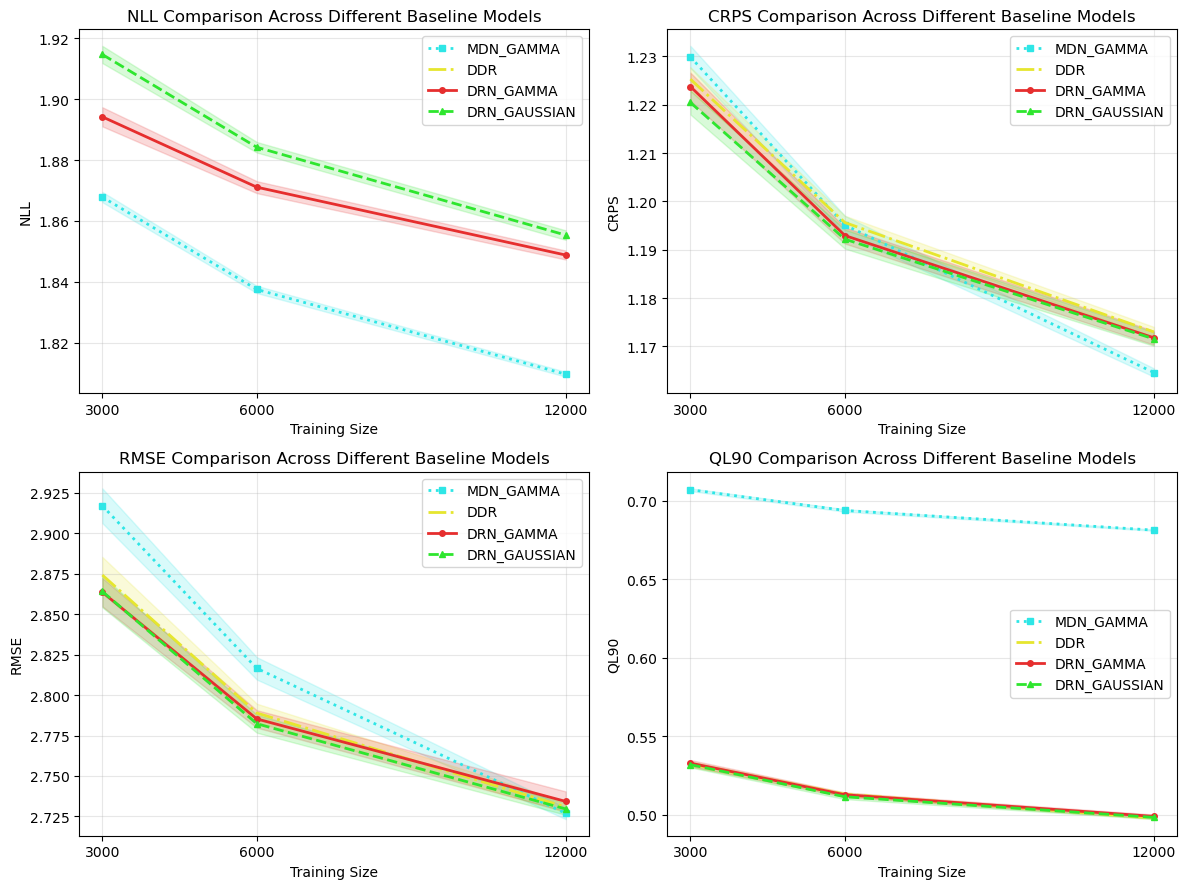

In [6]:
# DRN vs DDR vs MDN
model_order = [
    "MDN_GAMMA",
    "DDR",
    "DRN_GAMMA",
    "DRN_GAUSSIAN",
]

model_styles = {
    "DRN_GAMMA":    {"linestyle": "-",  "marker": "o"},  # solid + circles
    "DRN_GAUSSIAN": {"linestyle": "--", "marker": "^"},  # dashed + triangles
    "MDN_GAMMA":    {"linestyle": ":",  "marker": "s"},  # dotted + squares
    "DDR":          {"linestyle": "-.", "marker": None}, # dash-dot
}

model_colors = {m: GLOBAL_MODEL_COLORS[m] for m in model_order}

fig, axes = plot_metrics_grid(
    pd.concat((results_3000, results_6000, results_12000), axis=0),
    ci="sem95",
    model_order=model_order,
    model_colors=model_colors,
    model_styles=model_styles,
    show_only_trained_xticks=True,
    savepath=PLOT_DIR/"baseline_dependency_drn_vs_ddr_vs_mdn.png",
)
plt.show()


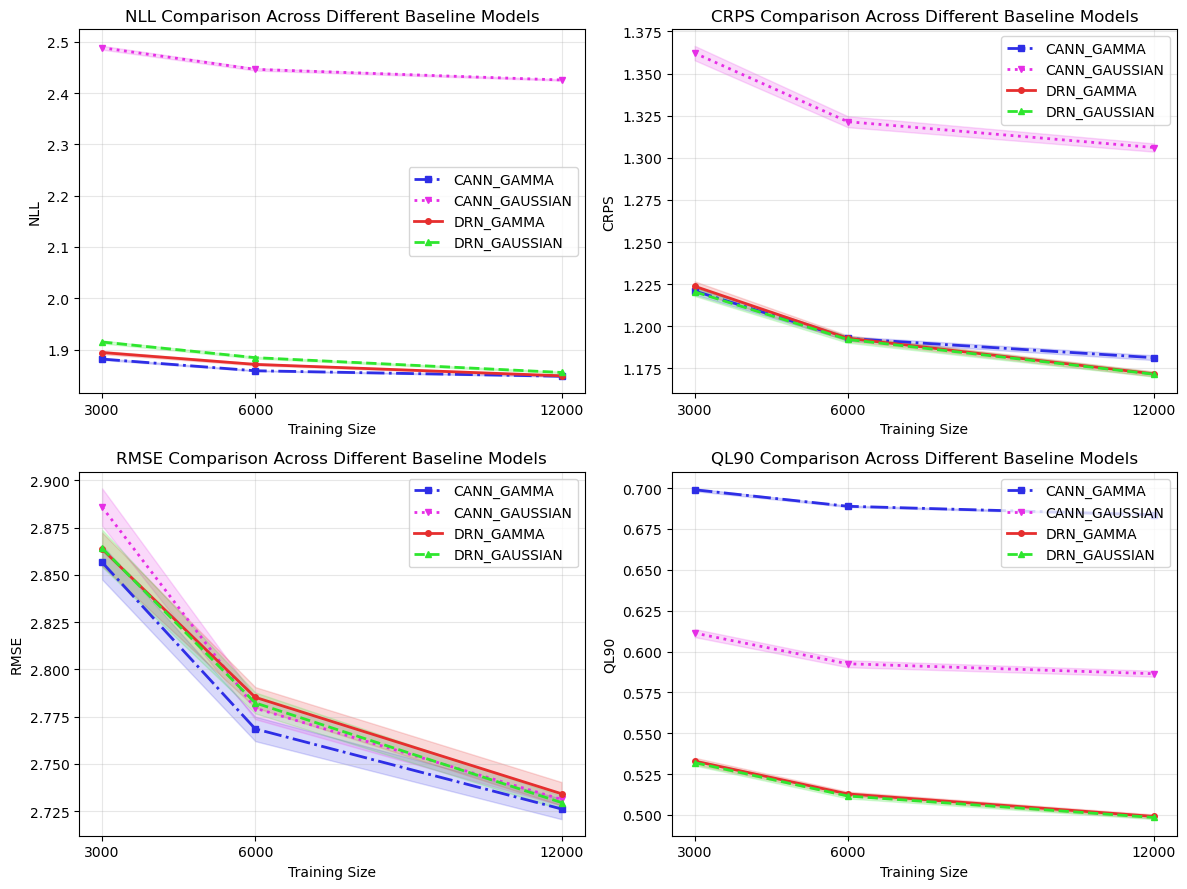

In [7]:
model_order = [
    "CANN_GAMMA",
    "CANN_GAUSSIAN",
    "DRN_GAMMA",
    "DRN_GAUSSIAN",
]

model_styles = {
    "CANN_GAMMA":   {"linestyle": "-.", "marker": "s"},  # dash-dot + squares
    "CANN_GAUSSIAN":{"linestyle": ":",  "marker": "v"},  # dotted + triangles-down
    "DRN_GAMMA":    {"linestyle": "-",  "marker": "o"},  # solid + circles
    "DRN_GAUSSIAN": {"linestyle": "--", "marker": "^"},  # dashed + triangles
}

model_colors = {m: GLOBAL_MODEL_COLORS[m] for m in model_order}

fig, axes = plot_metrics_grid(
    pd.concat((results_3000, results_6000, results_12000), axis=0),
    ci="sem95",
    model_order=model_order,
    model_colors=model_colors,
    model_styles=model_styles,
    show_only_trained_xticks=True,
    savepath=PLOT_DIR/"baseline_dependency_drn_vs_cann.png",
)
plt.show()


## Tables

In [8]:
import numpy as np
import pandas as pd
from collections import OrderedDict

# --- your summarizer (kept exactly as you wrote) ---
def _summarize(results, metric, ci="std"):
    """
    Summarize results by (model, train_size) for a given metric.

    ci: "std" (mean ± std), "sem95" (mean ± 1.96*sem), or "q10q90" (10–90%).
    """
    g = results.groupby(["model", "train_size"])[metric]
    mean = g.mean()
    std = g.std()/1.96
    n = g.count().astype(float)
    sem = std / np.sqrt(np.maximum(n, 1.0))
    q10 = g.quantile(0.1)
    q90 = g.quantile(0.9)

    df = pd.DataFrame({
        "mean": mean,
        "std": std.fillna(0.0),
        "n": n,
        "sem95": (1.96 * sem.fillna(0.0)),
        "q10": q10,
        "q90": q90
    }).reset_index()

    if ci == "std":
        df["lo"], df["hi"] = df["mean"] - df["std"], df["mean"] + df["std"]
    elif ci == "sem95":
        df["lo"], df["hi"] = df["mean"] - df["sem95"], df["mean"] + df["sem95"]
    elif ci == "q10q90":
        df["lo"], df["hi"] = df["q10"], df["q90"]
    else:
        raise ValueError("ci must be one of {'std','sem95','q10q90'}")
    return df.sort_values(["model", "train_size"])

# --- latex panel with flexible CI style ---
def _escape_latex(s: str) -> str:
    repl = {'\\': r'\textbackslash{}','&': r'\&','%': r'\%','$': r'\$','#': r'\#',
            '_': r'\_','{': r'\{','}': r'\}','~': r'\textasciitilde{}','^': r'\textasciicircum{}'}
    return ''.join(repl.get(ch, ch) for ch in str(s))

def make_panel_latex(
    results: pd.DataFrame,
    models: list[str],
    panel_title: str = "Top Panel",
    sizes: list | None = None,              # e.g. [600, 1800, 3600]
    size_col: str | None = None,            # 'size' or 'train_size'
    metrics: OrderedDict | None = None,     # {'NLL':'mean_nll', ...}
    ci: str = "std",                        # 'std' | 'sem95' | 'q10q90'
    decimals: int = 4,
    bold_best: bool = True,
    lower_is_better: dict | None = None,
    missing_token: str = r'--',
    summarizer = _summarize,                # pluggable summarizer
) -> str:

    if metrics is None:
        metrics = OrderedDict([('NLL','mean_nll'), ('CRPS','mean_crps'), ('RMSE','rmse'), ('QL90','ql_90')])
    if lower_is_better is None:
        lower_is_better = {k: True for k in metrics.keys()}

    # work on a copy and alias size column to 'train_size' for the summarizer
    df = results.copy()
    if size_col is None:
        if 'train_size' in df.columns:
            size_col = 'train_size'
        elif 'size' in df.columns:
            size_col = 'size'
        else:
            raise ValueError("Provide size_col (e.g., 'size' or 'train_size').")
    df['train_size'] = df[size_col]

    if sizes is None:
        sizes = sorted(df['train_size'].dropna().unique().tolist())

    # compute one summary per metric using the requested CI style
    summaries = {}
    for lab, col in metrics.items():
        if col not in df.columns:
            raise ValueError(f"Metric column '{col}' not found in results.")
        s = summarizer(df[['model', 'train_size', col]].rename(columns={col: 'val'})
                       .rename(columns={'val': col}),
                       metric=col, ci=ci)
        s = s[s['model'].isin(models) & s['train_size'].isin(sizes)]
        summaries[lab] = s

    # find winners by minimal (or maximal) mean inside each metric/size
    winners = {lab: {} for lab in metrics.keys()}
    for lab, s in summaries.items():
        for sz in sizes:
            block = s[(s['train_size'] == sz) & (s['model'].isin(models))]
            if block.empty:
                winners[lab][sz] = None
                continue
            means = block.set_index('model')['mean']
            if lower_is_better.get(lab, True):
                tgt = means.replace({np.inf: np.nan})
                best = tgt.idxmin() if tgt.notna().any() else None
            else:
                tgt = means.replace({-np.inf: np.nan})
                best = tgt.idxmax() if tgt.notna().any() else None
            winners[lab][sz] = best

    # latex header
    ncols = 2 + len(sizes)
    lines = []
    lines.append(r'\begin{tabular}{ll' + 'c'*len(sizes) + r'}')
    lines.append(r'\multicolumn{' + str(ncols) + r'}{c}{\textbf{' + _escape_latex(panel_title) + r'}} \\')
    lines.append(r'\toprule')
    lines.append(r'\textbf{Model} & \textbf{Metric} & ' +
                 ' & '.join(rf'\textbf{{{_escape_latex(s)}}}' for s in sizes) + r' \\')
    lines.append(r'\midrule')

    # cell formatter depending on ci mode
    def cell_str(row, is_best):
        if not np.isfinite(row['mean']):
            return r'$\infty$' if np.isinf(row['mean']) else missing_token

        m = f"{row['mean']:.{decimals}f}"
        if ci in ('std', 'sem95'):
            v = row[ci]
            vstr = f"{v:.{decimals}f}" if np.isfinite(v) else 'nan'
            txt = rf'{m} $\pm$ {vstr}'
        elif ci == 'q10q90':
            # en-dash in LaTeX = --
            q10 = f"{row['q10']:.{decimals}f}" if np.isfinite(row['q10']) else 'nan'
            q90 = f"{row['q90']:.{decimals}f}" if np.isfinite(row['q90']) else 'nan'
            txt = rf'{m} [{q10}--{q90}]'
        else:
            raise ValueError("ci must be one of {'std','sem95','q10q90'}")
        return rf'\textbf{{{txt}}}' if is_best and bold_best else txt

    # rows
    for i, (lab, _) in enumerate(metrics.items()):
        s = summaries[lab]
        for mdl in models:
            cells = [_escape_latex(mdl), lab]
            for sz in sizes:
                row = s[(s['model'] == mdl) & (s['train_size'] == sz)]
                if row.empty:
                    cells.append(missing_token)
                else:
                    r = row.iloc[0]
                    cells.append(cell_str(r, winners[lab].get(sz) == mdl))
            lines.append(' & '.join(cells) + r' \\')
        if i != len(metrics) - 1:
            lines.append(r'\addlinespace')
            lines.append(r'\midrule')

    lines.append(r'\bottomrule')
    lines.append(r'\end{tabular}')
    return '\n'.join(lines)


In [9]:

# --- Example ---
latex = make_panel_latex(
    results= pd.concat((results_3000,results_6000, results_12000), axis=0),
    models=['GLM_GAMMA','GLM_GAMMA_NULL','GLM_GAUSSIAN','GLM_GAUSSIAN_NULL',],
    panel_title='GLMs',
    sizes=[3000,6000,12000],
    size_col='size',   # or 'train_size'
    metrics=OrderedDict([('NLL','mean_nll'),('CRPS','mean_crps'),('RMSE','rmse'),('QL90','ql_90')]),
    ci='sem95',        # 'std' | 'sem95' | 'q10q90'
    decimals=4
)
print(latex)


\begin{tabular}{llccc}
\multicolumn{5}{c}{\textbf{GLMs}} \\
\toprule
\textbf{Model} & \textbf{Metric} & \textbf{3000} & \textbf{6000} & \textbf{12000} \\
\midrule
GLM\_GAMMA & NLL & \textbf{2.3149 $\pm$ 0.0038} & \textbf{2.3104 $\pm$ 0.0024} & \textbf{2.3116 $\pm$ 0.0022} \\
GLM\_GAMMA\_NULL & NLL & 2.3162 $\pm$ 0.0035 & 2.3135 $\pm$ 0.0018 & 2.3139 $\pm$ 0.0015 \\
GLM\_GAUSSIAN & NLL & 2.8264 $\pm$ 0.0007 & 2.8242 $\pm$ 0.0002 & 2.8238 $\pm$ 0.0002 \\
GLM\_GAUSSIAN\_NULL & NLL & 2.8472 $\pm$ 0.0006 & 2.8453 $\pm$ 0.0002 & 2.8451 $\pm$ 0.0002 \\
\addlinespace
\midrule
GLM\_GAMMA & CRPS & \textbf{1.7849 $\pm$ 0.0019} & \textbf{1.7813 $\pm$ 0.0016} & \textbf{1.7820 $\pm$ 0.0012} \\
GLM\_GAMMA\_NULL & CRPS & 1.8206 $\pm$ 0.0014 & 1.8193 $\pm$ 0.0007 & 1.8200 $\pm$ 0.0005 \\
GLM\_GAUSSIAN & CRPS & 1.9049 $\pm$ 0.0047 & 1.8986 $\pm$ 0.0022 & 1.8989 $\pm$ 0.0017 \\
GLM\_GAUSSIAN\_NULL & CRPS & 1.9570 $\pm$ 0.0047 & 1.9525 $\pm$ 0.0021 & 1.9535 $\pm$ 0.0016 \\
\addlinespace
\midrule
GLM\_GAMM

In [10]:

# --- Example ---
latex = make_panel_latex(
    results= pd.concat((results_3000,results_6000, results_12000), axis=0),
    models=['DRN_GAMMA','DRN_GAMMA_NULL','DRN_GAUSSIAN','DRN_GAUSSIAN_NULL',],
    panel_title='DRNs',
    sizes=[3000,6000,12000],
    size_col='size',   # or 'train_size'
    metrics=OrderedDict([('NLL','mean_nll'),('CRPS','mean_crps'),('RMSE','rmse'),('QL90','ql_90')]),
    ci='sem95',        # 'std' | 'sem95' | 'q10q90'
    decimals=4
)
print(latex)


\begin{tabular}{llccc}
\multicolumn{5}{c}{\textbf{DRNs}} \\
\toprule
\textbf{Model} & \textbf{Metric} & \textbf{3000} & \textbf{6000} & \textbf{12000} \\
\midrule
DRN\_GAMMA & NLL & 1.8942 $\pm$ 0.0031 & 1.8711 $\pm$ 0.0020 & \textbf{1.8488 $\pm$ 0.0015} \\
DRN\_GAMMA\_NULL & NLL & \textbf{1.8936 $\pm$ 0.0031} & \textbf{1.8694 $\pm$ 0.0021} & 1.8490 $\pm$ 0.0014 \\
DRN\_GAUSSIAN & NLL & 1.9147 $\pm$ 0.0028 & 1.8842 $\pm$ 0.0017 & 1.8553 $\pm$ 0.0016 \\
DRN\_GAUSSIAN\_NULL & NLL & 1.9106 $\pm$ 0.0031 & 1.8785 $\pm$ 0.0019 & 1.8567 $\pm$ 0.0017 \\
\addlinespace
\midrule
DRN\_GAMMA & CRPS & 1.2238 $\pm$ 0.0029 & 1.1929 $\pm$ 0.0017 & 1.1718 $\pm$ 0.0014 \\
DRN\_GAMMA\_NULL & CRPS & 1.2228 $\pm$ 0.0023 & 1.1911 $\pm$ 0.0017 & 1.1725 $\pm$ 0.0013 \\
DRN\_GAUSSIAN & CRPS & \textbf{1.2205 $\pm$ 0.0025} & 1.1922 $\pm$ 0.0020 & \textbf{1.1715 $\pm$ 0.0014} \\
DRN\_GAUSSIAN\_NULL & CRPS & 1.2229 $\pm$ 0.0033 & \textbf{1.1910 $\pm$ 0.0021} & 1.1727 $\pm$ 0.0015 \\
\addlinespace
\midrule
DRN\_GAMM

In [11]:

# --- Example ---
latex = make_panel_latex(
    results= pd.concat((results_3000,results_6000, results_12000), axis=0),
    models=['CANN_GAMMA','CANN_GAMMA_NULL','CANN_GAUSSIAN','CANN_GAUSSIAN_NULL',],
    panel_title='CANNs',
    sizes=[3000,6000,12000],
    size_col='size',   # or 'train_size'
    metrics=OrderedDict([('NLL','mean_nll'),('CRPS','mean_crps'),('RMSE','rmse'),('QL90','ql_90')]),
    ci='sem95',        # 'std' | 'sem95' | 'q10q90'
    decimals=4
)
print(latex)


\begin{tabular}{llccc}
\multicolumn{5}{c}{\textbf{CANNs}} \\
\toprule
\textbf{Model} & \textbf{Metric} & \textbf{3000} & \textbf{6000} & \textbf{12000} \\
\midrule
CANN\_GAMMA & NLL & \textbf{1.8814 $\pm$ 0.0017} & \textbf{1.8587 $\pm$ 0.0008} & \textbf{1.8480 $\pm$ 0.0008} \\
CANN\_GAMMA\_NULL & NLL & 1.8828 $\pm$ 0.0022 & 1.8593 $\pm$ 0.0011 & 1.8487 $\pm$ 0.0011 \\
CANN\_GAUSSIAN & NLL & 2.4883 $\pm$ 0.0037 & 2.4463 $\pm$ 0.0024 & 2.4255 $\pm$ 0.0012 \\
CANN\_GAUSSIAN\_NULL & NLL & 2.4912 $\pm$ 0.0038 & 2.4495 $\pm$ 0.0022 & 2.4263 $\pm$ 0.0009 \\
\addlinespace
\midrule
CANN\_GAMMA & CRPS & \textbf{1.2210 $\pm$ 0.0022} & \textbf{1.1928 $\pm$ 0.0013} & \textbf{1.1814 $\pm$ 0.0014} \\
CANN\_GAMMA\_NULL & CRPS & 1.2231 $\pm$ 0.0026 & 1.1942 $\pm$ 0.0017 & 1.1821 $\pm$ 0.0015 \\
CANN\_GAUSSIAN & CRPS & 1.3621 $\pm$ 0.0043 & 1.3214 $\pm$ 0.0033 & 1.3061 $\pm$ 0.0024 \\
CANN\_GAUSSIAN\_NULL & CRPS & 1.3631 $\pm$ 0.0048 & 1.3230 $\pm$ 0.0034 & 1.3086 $\pm$ 0.0029 \\
\addlinespace
\midrule


In [12]:

# --- Example ---
latex = make_panel_latex(
    results= pd.concat((results_3000,results_6000, results_12000), axis=0),
    models=['MDN_GAMMA','DDR','DRN_GAMMA','DRN_GAUSSIAN',],
    panel_title='MDNs vs DDRs vs DRNs',
    sizes=[3000,6000,12000],
    size_col='size',   # or 'train_size'
    metrics=OrderedDict([('NLL','mean_nll'),('CRPS','mean_crps'),('RMSE','rmse'),('QL90','ql_90')]),
    ci='sem95',        # 'std' | 'sem95' | 'q10q90'
    decimals=4
)
print(latex)


\begin{tabular}{llccc}
\multicolumn{5}{c}{\textbf{MDNs vs DDRs vs DRNs}} \\
\toprule
\textbf{Model} & \textbf{Metric} & \textbf{3000} & \textbf{6000} & \textbf{12000} \\
\midrule
MDN\_GAMMA & NLL & \textbf{1.8679 $\pm$ 0.0017} & \textbf{1.8375 $\pm$ 0.0012} & \textbf{1.8096 $\pm$ 0.0008} \\
DDR & NLL & $\infty$ & $\infty$ & $\infty$ \\
DRN\_GAMMA & NLL & 1.8942 $\pm$ 0.0031 & 1.8711 $\pm$ 0.0020 & 1.8488 $\pm$ 0.0015 \\
DRN\_GAUSSIAN & NLL & 1.9147 $\pm$ 0.0028 & 1.8842 $\pm$ 0.0017 & 1.8553 $\pm$ 0.0016 \\
\addlinespace
\midrule
MDN\_GAMMA & CRPS & 1.2299 $\pm$ 0.0023 & 1.1951 $\pm$ 0.0019 & \textbf{1.1646 $\pm$ 0.0009} \\
DDR & CRPS & 1.2253 $\pm$ 0.0025 & 1.1956 $\pm$ 0.0014 & 1.1730 $\pm$ 0.0011 \\
DRN\_GAMMA & CRPS & 1.2238 $\pm$ 0.0029 & 1.1929 $\pm$ 0.0017 & 1.1718 $\pm$ 0.0014 \\
DRN\_GAUSSIAN & CRPS & \textbf{1.2205 $\pm$ 0.0025} & \textbf{1.1922 $\pm$ 0.0020} & 1.1715 $\pm$ 0.0014 \\
\addlinespace
\midrule
MDN\_GAMMA & RMSE & 2.9170 $\pm$ 0.0107 & 2.8165 $\pm$ 0.0069 & \textb

---

### Notes
- To change sizes, edit `EVAL_SIZES` in the *Seeds, sizes & training hyperparameters* cell.
- To run more seeds, increase `MAX_SEEDS_TO_RUN` there as well.
- If you're on a single GPU, parallelism is set to 1 automatically to avoid contention.
- This notebook mirrors the exact model set from your original file and exports the CSV in the same format:
  `tables/baseline-test/revision_baseline_dependency_{Nseeds}seeds_{sizes}.csv`.
